In [1]:
import sys
sys.path.append('..')

from eval_lsh import *

def compute_map_mrr(scores, labels):
    ranking = scores.argsort(dim=1, descending=True)
    ranked_output = torch.gather(labels, dim=1, index=ranking)

    MRR = (1 / (ranked_output.argmax(dim=1) + 1)).mean().item()

    MAP = (torch.cumsum(ranked_output, dim=1) * ranked_output).float()
    MAP /= (torch.arange(ranked_output.shape[1]) + 1)
    MAP /= torch.sum(ranked_output, dim=1, keepdim=True)
    MAP = MAP.sum(dim=1).mean().item()
    return MAP, MRR

In [2]:
dataset = "audio"
expt_id = "A01091914"
hasher_expt_num = 24
DEVICE = "cuda:6"

hasher_expt_root = f"../hashing/{expt_id}/{hasher_expt_num}/"
saved_gt_path = f"../hashing/{expt_id}_embeds_gt.pkl"

hasher = torch.load(f"{hasher_expt_root}/hasher_best.pt", map_location=DEVICE)
hasher = hasher.eval()

savedict = torch.load(saved_gt_path)
corpus_embedded = savedict["corpus"].cpu()
labels = savedict["labels"].cpu()
global_scores = savedict["scores"].cpu()
test_query_embedded = savedict["queries"].cpu()
print("Loaded ground truth")

Loaded ground truth


In [3]:
with torch.no_grad():
    corpus_embedded_out = []
    for i in range(0,len(corpus_embedded),200):
        corpus_embedded_out.append(hasher[1](corpus_embedded[i:i+200].to(DEVICE)).cpu())
    corpus_embedded = torch.vstack(corpus_embedded_out)
    test_query_embedded = hasher[0](test_query_embedded.to(DEVICE)).cpu()

In [4]:
perf = dict()

# 0. s(q,c) = OPAS_{s}(q,c)

In [5]:
MAP, MRR = compute_map_mrr(global_scores, labels)
print(f"Original OPAS Scores -- MAP: {MAP:.4f}, MRR: {MRR:.4f}")
perf["OPAS"] = (MAP, MRR)

Original OPAS Scores -- MAP: 0.9990, MRR: 0.9988


# 1. $s(q,c) = \langle q,c \rangle$

In [6]:
netscores = test_query_embedded @ corpus_embedded.T
MAP, MRR = compute_map_mrr(netscores, labels)
print(f"Dot Product Scores -- MAP: {MAP:.4f}, MRR: {MRR:.4f}")
perf["IP"] = (MAP, MRR)

Dot Product Scores -- MAP: 0.5823, MRR: 0.5952


# 2. $s(q,c) = \frac{\langle q,c \rangle}{||q||\cdot||c||}$

In [7]:
netscores = test_query_embedded @ corpus_embedded.T / (torch.norm(test_query_embedded, dim=-1, keepdim=True) * torch.norm(corpus_embedded, dim=-1, keepdim=True).T)
MAP, MRR = compute_map_mrr(netscores, labels)
print(f"Cosine Similarity Scores -- MAP: {MAP:.4f}, MRR: {MRR:.4f}")
perf["CS"] = (MAP, MRR)

Cosine Similarity Scores -- MAP: 0.5836, MRR: 0.6001


In [8]:
import pandas as pd
df = pd.DataFrame(perf).T
df = df.reset_index()
df.columns = ["Method", "MAP", "MRR"]
df

,Method,MAP,MRR
0,OPAS,0.999028,0.998813
1,IP,0.582349,0.595185
2,CS,0.583605,0.600086


# 3. FAISS

In [9]:
from plot_params import *

In [29]:
import faiss

def get_faiss_map(lsh, k):
    _, I = lsh.search(test_query_embedded.numpy(), k=k)
    I = torch.from_numpy(I)
    ret_scores = global_scores.gather(1, I)
    ret_labels = labels.gather(1, I)
    ap = []
    for i in range(len(test_query_embedded)):
        total_rel = labels[i].sum()
        l = ret_labels[i]
        scores = ret_scores[i]
        ap.append(average_precision_score(l, scores))
    return np.mean(ap)

def faiss_map_for_k_list(lsh, klist):
    _map = dict()
    for k in tqdm(list(klist)):
        try:
            _map[k] = get_faiss_map(lsh, int(k))
        except:
            print(f"Error with k={k}")
            continue
    _map = np.array(list(_map.items()))
    return _map[:,0], _map[:,1]

In [11]:
import pickle

d = corpus_embedded.shape[1]
if True:
    with open("data/faiss_audio.pkl", "rb") as f:
        all_map = pickle.load(f)
else:
    all_map = dict()
    for m in [10, 20, 50, 100]:
        # m = 10
        lsh = faiss.IndexLSH(d, m)
        lsh.train(corpus_embedded.numpy())
        lsh.add(corpus_embedded.numpy())
        _map = dict()
        for k in tqdm([10, 100, 1000, 5000, 10000, len(corpus_embedded)], desc=f"LSH evaluation (m={m})"):
            _map[k] = get_faiss_map(lsh, k)
        _map = np.array(list(_map.items()))
        all_map[m] = _map

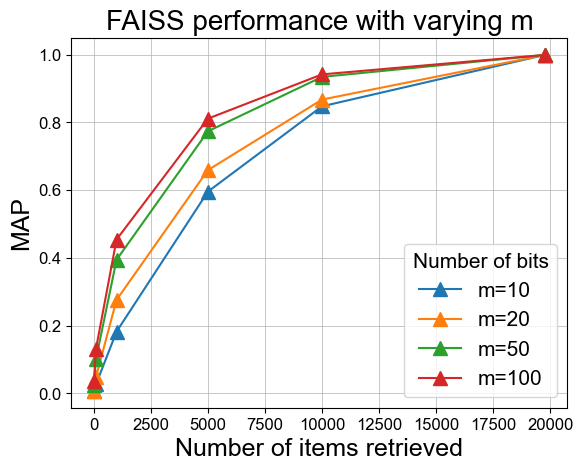

In [13]:
list(all_map.items())

from plots_and_figures.plot_params import *

for m in all_map.keys():
    if type(m) != int:
        continue
    plt.plot(all_map[m][:,0], all_map[m][:,1], "^-", markersize=10, label=f"m={m}")
plt.title("FAISS performance with varying m", fontsize=title_fontsize)
plt.xticks(fontsize=label_fontsize)
plt.yticks(fontsize=label_fontsize)
plt.legend(title="Number of bits", fontsize=15, title_fontsize=15)
plt.xlabel("Number of items retrieved", fontsize=axis_fontsize)
plt.ylabel("MAP", fontsize=axis_fontsize)
plt.grid(linewidth=0.5)
plt.savefig("faiss_audio_m.pdf", bbox_inches="tight")
plt.show()

## Compare FAISS with OPAS + trained hplane

In [14]:
with open(f"data/lsh_multi_final_{dataset}.pkl", "rb") as f:
    lss = pickle.load(f)

best_perf = lss[29][3:]     # idx 29 has the best hparam set
opas_map = best_perf[::3]
opas_ret = best_perf[1::3]
faiss_map = all_map["aligned"][:,1]
faiss_ret = all_map["aligned"][:,0]

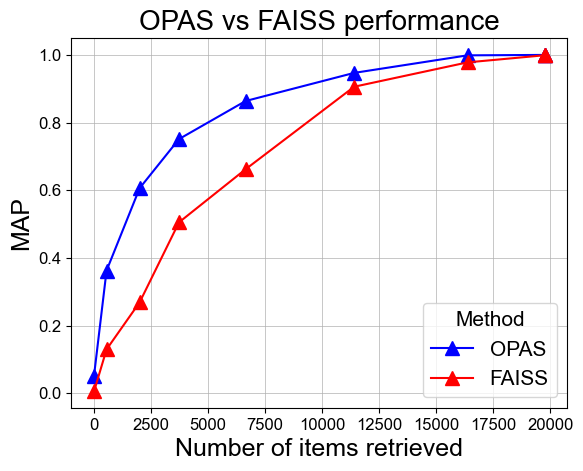

In [15]:
plt.plot(opas_ret, opas_map, "^-", markersize=10, label="OPAS", color="blue")#tab:blue")
plt.plot(faiss_ret, faiss_map, "^-", markersize=10, label="FAISS", color="red")#tab:orange")
plt.title("OPAS vs FAISS performance", fontsize=title_fontsize)
plt.xticks(fontsize=label_fontsize)
plt.yticks(fontsize=label_fontsize)
plt.legend(title="Method", fontsize=15, title_fontsize=15)
plt.xlabel("Number of items retrieved", fontsize=axis_fontsize)
plt.ylabel("MAP", fontsize=axis_fontsize)
plt.grid(linewidth=0.5)
plt.savefig("opas_vs_faiss.pdf", bbox_inches="tight")
plt.show()

# Using FAISS Indexes

In [16]:
import faiss
from itertools import chain

try:
    flatl2_ret, flatl2_map = all_map["flatl2"].T
    flatip_ret, flatip_map = all_map["flatip"].T
    
except:
    index_flat = faiss.IndexFlatL2(d)
    index_flat.add(corpus_embedded.numpy())
    index_flat.nprobe = 5

    index_flatip = faiss.IndexFlatIP(d)
    index_flatip.add(corpus_embedded.numpy())
    index_flatip.nprobe = 5

    kvals = list(chain([10], opas_ret[1:]))

    flatl2_ret, flatl2_map = faiss_map_for_k_list(index_flat, kvals)
    flatip_ret, flatip_map = faiss_map_for_k_list(index_flatip, kvals)

In [30]:
try:
    flativf_ret, flativf_map = all_map["flativf"].T

except:
    quant = faiss.IndexFlatL2(d)
    index_ivf = faiss.IndexIVFFlat(quant, d, 2, faiss.METRIC_L2)
    index_ivf.train(corpus_embedded.numpy())
    index_ivf.add(corpus_embedded.numpy())

    kvals = list(chain([10], opas_ret[1:]))
    flativf_ret, flativf_map = faiss_map_for_k_list(index_ivf, kvals)

 56%|███████████████████████████████████████████████████████████████▉                                                   | 5/9 [00:10<00:07,  1.90s/it]

Error with k=6645.69


 67%|████████████████████████████████████████████████████████████████████████████▋                                      | 6/9 [00:10<00:04,  1.35s/it]

Error with k=11401.67


 78%|█████████████████████████████████████████████████████████████████████████████████████████▍                         | 7/9 [00:11<00:02,  1.03s/it]

Error with k=16371.01


 89%|██████████████████████████████████████████████████████████████████████████████████████████████████████▏            | 8/9 [00:11<00:00,  1.20it/s]

Error with k=19751.84


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 9/9 [00:11<00:00,  1.33s/it]

Error with k=19760.0


In [32]:
all_map["flatl2"] = np.array([flatl2_ret, flatl2_map]).T
all_map["flatip"] = np.array([flatip_ret, flatip_map]).T
all_map["flativf"] = np.array([flativf_ret, flativf_map]).T

with open("data/faiss_audio.pkl", "wb") as f:
    pickle.dump(all_map, f)

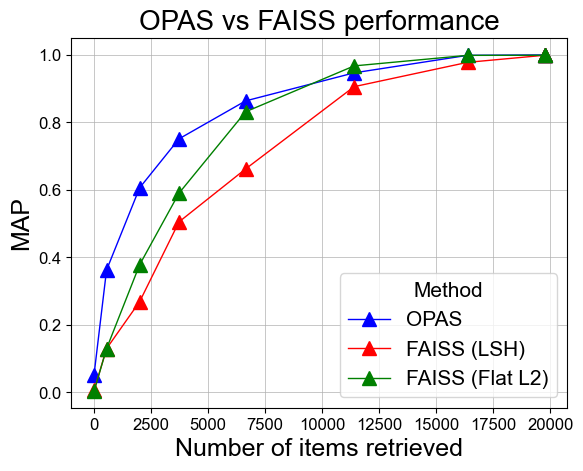

In [ ]:
linewidth = 1
kwargs = {
    "markersize": 10,
    "linewidth": linewidth,
    "alpha": 1
}

plt.plot(opas_ret, opas_map, "^-", label="OPAS", color="blue", **kwargs)
plt.plot(faiss_ret, faiss_map, "^-", label="FAISS (LSH)", color="red", **kwargs)
plt.plot(flatl2_ret, flatl2_map, "^-", label="FAISS (Flat L2)", color="green", **kwargs)
# plt.plot(flatip_ret, flatip_map, "^-", label="FAISS (Flat IP)", color="orange", **kwargs)
# plt.plot(flativf_ret, flativf_map, "^-", label="FAISS (Flat IVF L2)", color="orange", **kwargs)
plt.title("OPAS vs FAISS performance", fontsize=title_fontsize)
plt.xticks(fontsize=label_fontsize)
plt.yticks(fontsize=label_fontsize)
plt.legend(title="Method", fontsize=legend_fontsize, title_fontsize=legend_fontsize)
plt.xlabel("Number of items retrieved", fontsize=axis_fontsize)
plt.ylabel("MAP", fontsize=axis_fontsize)
plt.grid(linewidth=0.5)
# plt.savefig("opas_vs_faiss.pdf", bbox_inches="tight")
plt.show()